# Atividade Prática 6


Aluno: João Gabriel Angelo Bradachi

Professor: Fabrício Silva

Objetivo: Aplicar dois algoritmos distintos de aprendizado no conjunto de dados breastcancerwisconsin.csv

Para cada um, calcular as métricas de acurácia, precisão, revocação, especificidade, f1-score. Plotar também a  curva ROC e calcular a AUC.

Para cada um irei aplicar PCA e fazer o ajuste dos hiper parametros.


In [34]:
# imports
import pandas as pd

from time import time

import optuna
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import numpy as np


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [4]:
# Obtendo dados
df_cancer = pd.read_csv("breastcancerwisconsin.csv")
df_cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


## Análise exploratória

Vamos fazer uma pequena análise exploratória e ajustar os dados para o PCA


In [5]:
df_cancer.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [6]:
df_cancer.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

## Preparando os dados

- Retirando colunas desnecessárias
- Padronizando os dados
- Aplicando PCA

In [7]:
# preparando os dados

encoder = LabelEncoder()

X = df_cancer.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
y = encoder.fit_transform(df_cancer['diagnosis'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA com 95% da variância original
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Colunas originais: {X.shape[1]}")
print(f"Colunas após PCA: {X_pca.shape[1]}")
print(f"Variância retida: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Colunas originais: 30
Colunas após PCA: 10
Variância retida: 95.16%


## Ajustando hiperparametros do XGBoost

In [10]:
def objective(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 300),
      'max_depth': trial.suggest_int('max_depth', 3, 9),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
  }

  model = XGBClassifier(**params)

  # Validação cruzada com 5 folds
  scores = cross_val_score(model, X_pca, y, cv=5, scoring='accuracy', verbose=1)
  return scores.mean()


# Executando o estudo
start = time()
study_XGBoost = optuna.create_study(direction='maximize')

study_XGBoost.optimize(objective, n_trials=100)
print(f"Tempo para treinar 5 vezes com 5 cross validations: {time()-start} segundos")
print('Melhores parâmetros:', study_XGBoost.best_params)

[I 2026-09-23 18:14:23,802] A new study created in memory with name: no-name-c5128c1d-06b7-4f95-8058-3dbc4e1d52df
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished
[I 2026-09-23 18:14:24,242] Trial 0 finished with value: 0.9613724576929048 and parameters: {'n_estimators': 102, 'max_depth': 6, 'learning_rate': 0.08717516443932337, 'subsample': 0.8764747009617369, 'colsample_bytree': 0.6876220586304829}. Best is trial 0 with value: 0.9613724576929048.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished
[I 2026-09-23 18:14:24,542] Trial 1 finished with value: 0.9490607048594939 and parameters: {'n_estimators': 107, 'max_depth': 3, 'learning_rate': 0.020708618095519393, 'subsample': 0.8557558459601916, 'colsample_bytree': 0.8063819482922794}. Best is trial 0 with value: 0.9613724576929048.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    1.8s finished
[I 2026-09-23 18:14:26,387] Trial 2 finished with value: 0.9525694767893185 and parameters: {'n

Tempo para treinar 5 vezes com 5 cross validations: 108.80803799629211 segundos
Melhores parâmetros: {'n_estimators': 260, 'max_depth': 4, 'learning_rate': 0.10556199647061293, 'subsample': 0.6157935107064498, 'colsample_bytree': 0.936845321412195}


## Ajustando hiperparametros da Regressão Logística

In [21]:
def objective(trial):
  params = {
      'C': trial.suggest_float('C', 0.01, 100),
      'penalty': trial.suggest_categorical('penalty', ['l2', None]),
      'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
      'max_iter': trial.suggest_int('max_iter', 100, 2000),
      'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
  }

  model = LogisticRegression(**params)

  # Validação cruzada com 5 folds
  scores = cross_val_score(model, X_pca, y, cv=5, scoring='accuracy', verbose=1)
  return scores.mean()


# Executando o estudo
start = time()
study_RL = optuna.create_study(direction='maximize')

study_RL.optimize(objective, n_trials=100)
print(f"Tempo para treinar 5 vezes com 5 cross validations: {time()-start} segundos")
print('Melhores parâmetros:', study_RL.best_params)

[I 2026-09-23 18:26:26,426] A new study created in memory with name: no-name-774bf939-99a1-4385-b2e4-2f36172fb187
/home/bradachi/Documentos/gitpath/ML-engineering-final-project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bradachi/Documentos/gitpath/ML-engineering-final-project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', 

Tempo para treinar 5 vezes com 5 cross validations: 17.773550987243652 segundos
Melhores parâmetros: {'C': 70.12390563257169, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 238, 'class_weight': None}


## Ajustando hiperparametros do Naïve Bayes

In [23]:
def objective(trial):
  params = {
      'var_smoothing': trial.suggest_int('var_smoothing', 1e-11, 1e-1),
  }

  model = GaussianNB(**params)

  # Validação cruzada com 5 folds
  scores = cross_val_score(model, X_pca, y, cv=5, scoring='accuracy', verbose=1)
  return scores.mean()


# Executando o estudo
start = time()
study_NB = optuna.create_study(direction='maximize')

study_NB.optimize(objective, n_trials=100)
print(f"Tempo para treinar 5 vezes com 5 cross validations: {time()-start} segundos")
print(f'Melhores parâmetros: {study_NB.best_params}')

[I 2026-09-23 18:29:32,583] A new study created in memory with name: no-name-cd5eee0a-945f-4867-9b4d-cd6df265274d
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[I 2026-09-23 18:29:32,603] Trial 0 finished with value: 0.9279459711224964 and parameters: {'var_smoothing': 0}. Best is trial 0 with value: 0.9279459711224964.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[I 2026-09-23 18:29:32,625] Trial 1 finished with value: 0.9279459711224964 and parameters: {'var_smoothing': 0}. Best is trial 0 with value: 0.9279459711224964.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[I 2026-09-23 18:29:32,651] Trial 2 finished with value: 0.9279459711224964 and parameters: {'var_smoothing': 0}. Best is trial 0 with value: 0.9279459711224964.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[I 2026-09-23 18:29:32,681] Trial 3 finished with value: 0.9279459711224964 and parameters: {'var_smoothing': 0}. Best i

Tempo para treinar 5 vezes com 5 cross validations: 2.5484519004821777 segundos
Melhores parâmetros: {'var_smoothing': 0}


## Melhor modelo XGBoost

In [35]:
melhores_parametros = study_XGBoost.best_params

X_treino, X_teste, y_treino, y_teste = train_test_split(X_pca, y, test_size=0.2, random_state=42)

modelo_pipeline_XGB = Pipeline(steps=[
    ('classificador', XGBClassifier(**melhores_parametros))
])

print("Treinando o modelo...")
modelo_pipeline_XGB.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline_XGB.predict(X_teste)
categorias_texto = encoder.inverse_transform(previsoes)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, digits=5))

Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

           0    0.97222   0.98592   0.97902        71
           1    0.97619   0.95349   0.96471        43

    accuracy                        0.97368       114
   macro avg    0.97421   0.96970   0.97186       114
weighted avg    0.97372   0.97368   0.97362       114



In [36]:
melhores_parametros = study_RL.best_params

X_treino, X_teste, y_treino, y_teste = train_test_split(X_pca, y, test_size=0.2, random_state=42)

modelo_pipeline_RL = Pipeline(steps=[
    ('classificador', LogisticRegression(**melhores_parametros))
])

print("Treinando o modelo...")
modelo_pipeline_RL.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline_RL.predict(X_teste)
categorias_texto = encoder.inverse_transform(previsoes)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, digits=5))

Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

           0    0.98592   0.98592   0.98592        71
           1    0.97674   0.97674   0.97674        43

    accuracy                        0.98246       114
   macro avg    0.98133   0.98133   0.98133       114
weighted avg    0.98246   0.98246   0.98246       114



/home/bradachi/Documentos/gitpath/ML-engineering-final-project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bradachi/Documentos/gitpath/ML-engineering-final-project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [37]:
melhores_parametros = study_NB.best_params

X_treino, X_teste, y_treino, y_teste = train_test_split(X_pca, y, test_size=0.2, random_state=42)

modelo_pipeline_NB = Pipeline(steps=[
    ('classificador', GaussianNB(**melhores_parametros))
])

print("Treinando o modelo...")
modelo_pipeline_NB.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline_NB.predict(X_teste)
categorias_texto = encoder.inverse_transform(previsoes)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, digits=5))

Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

           0    0.90789   0.97183   0.93878        71
           1    0.94737   0.83721   0.88889        43

    accuracy                        0.92105       114
   macro avg    0.92763   0.90452   0.91383       114
weighted avg    0.92278   0.92105   0.91996       114



In [32]:
dados = {"XGB":
              {"accuracy": 0.97368,
               "precision": 0.97372,
               "recall": 0.97368,
               "f1-score": 0.97362},
              "LR":
              {"accuracy": 0.98246,
               "precision": 0.98246,
               "recall": 0.98246,
               "f1-score": 0.98246},
              "NB":
              {"accuracy": 0.92105,
               "precision": 0.92278,
               "recall": 0.92105,
               "f1-score": 0.91996},}

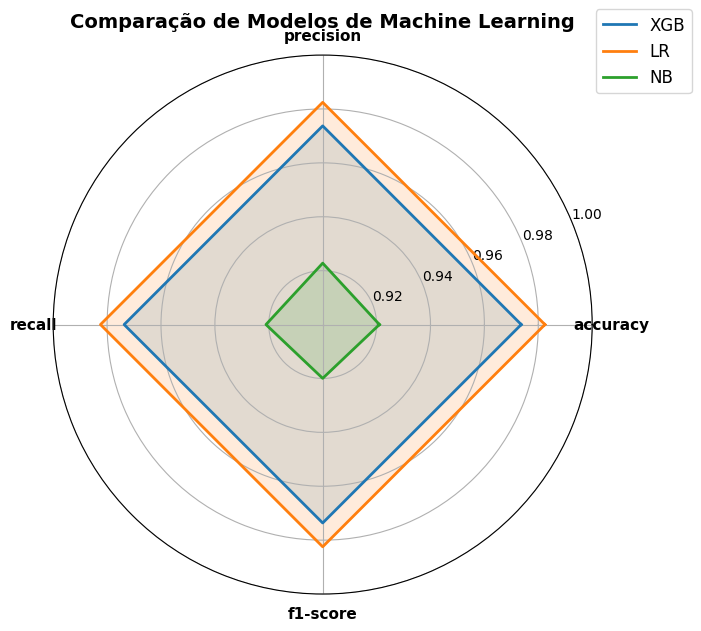

In [33]:
# usei o gemini para gerar esse código

import matplotlib.pyplot as plt
import numpy as np

categorias = list(dados["XGB"].keys())
num_categorias = len(categorias)

angulos = np.linspace(0, 2 * np.pi, num_categorias, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

cores = {"XGB": "#1f77b4", "LR": "#ff7f0e", "NB": "#2ca02c"}

for modelo, metricas in dados.items():
    
    valores = [metricas[cat] for cat in categorias]
    
    valores += valores[:1]
    
    
    ax.plot(angulos, valores, linewidth=2, label=modelo, color=cores[modelo])
    ax.fill(angulos, valores, alpha=0.15, color=cores[modelo])


ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11, fontweight='bold')


ax.set_ylim(0.90, 1.0)  


plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)


plt.title("Comparação de Modelos de Machine Learning", fontsize=14, pad=20, fontweight='bold')
plt.show()


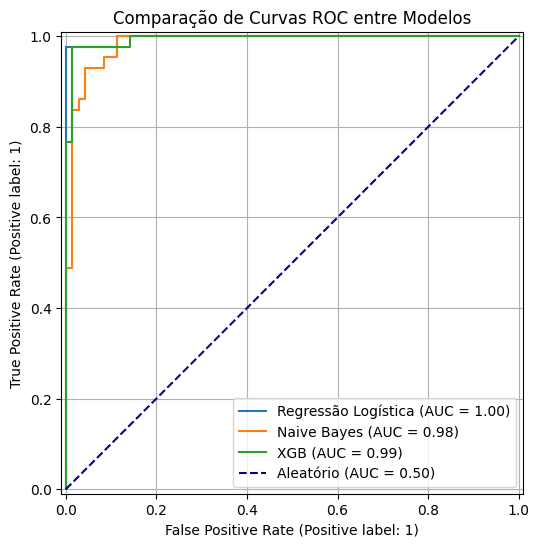

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(modelo_pipeline_RL, X_teste, y_teste, ax=ax, name='Regressão Logística')
RocCurveDisplay.from_estimator(modelo_pipeline_NB, X_teste, y_teste, ax=ax, name='Naive Bayes')
RocCurveDisplay.from_estimator(modelo_pipeline_XGB, X_teste, y_teste, ax=ax, name='XGB')

# 6. Personalizar o gráfico
ax.plot([0, 1], [0, 1], linestyle='--', color='navy', label='Aleatório (AUC = 0.50)')
ax.set_title('Comparação de Curvas ROC entre Modelos')
ax.legend(loc='lower right')
ax.grid(True)

# 7. Exibir o gráfico
plt.show()

## Resultados

Com os relatórios de classificação e os gráficos plotados podemos perceber que, para esse problema de classificação, a Regressão Logística com PCA se saiu melhor em todas as métricas, seguido pelo XGBoost e pelo Naive Bayes

## Conclusão

O trabalho foi concluido com sucesso, todos os objetivos foram concluidos aplicando as técnicas vistas em sala de aula